In [2]:
import numpy as np
import pandas as pd
import math, random
import matplotlib.pyplot as plt

Sequence used (X): GGATTCACCTTCAGTAGCTATAGC
Log-likelihood under PSSM: -2.2623919333580775
Mean pairwise Hamming (natural_pool): 3.595534258564641
Mean pairwise Hamming (mutated_from_X): 5.475666666666666
Mean per-position JS divergence (bits): 0.020923725156119233
Per-position entropy (bits) mean: 0.46978133339558587


/tmp/ipykernel_10254/783609136.py:48: RuntimeWarning: divide by zero encountered in log2
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
/tmp/ipykernel_10254/783609136.py:48: RuntimeWarning: invalid value encountered in multiply
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)


Saved histogram CSV to pssm_pairwise_hamming_hist.csv


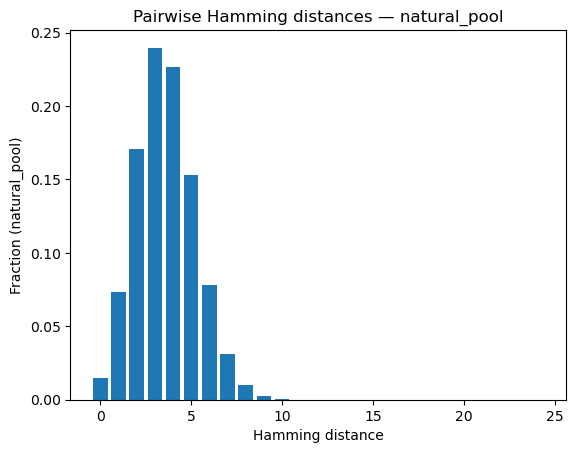

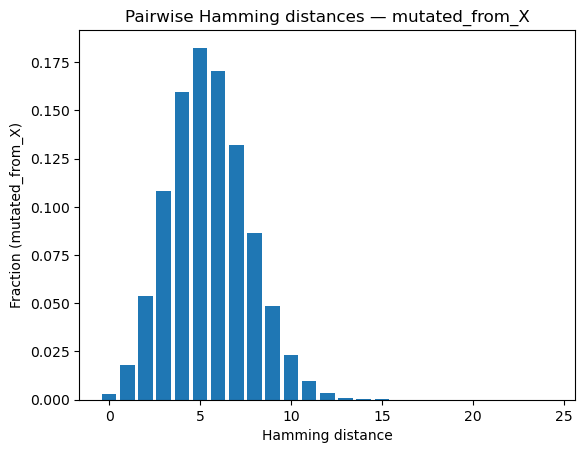

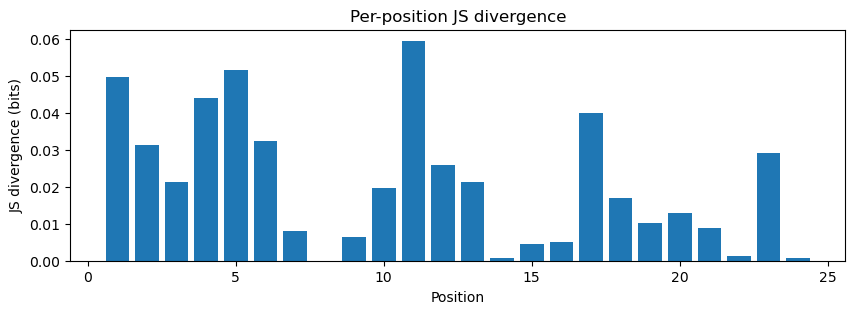

In [3]:
#FOR CDR_1 WITH RANDOMLY GENERATED SEQUENCES (ДЛЯ ПРОВЕРКИ РАБОТЫ)
pssm_path = "Downloads/cdr1_nucleotide_frequencies.csv"

raw = pd.read_csv(pssm_path)
raw = raw.set_index(raw.columns[0])

row_order = []
for r in ['A','C','G','T']:
    for idx in raw.index:
        if str(idx).upper() == r:
            row_order.append(idx)
            break
raw = raw.loc[row_order]

pssm_df = raw.transpose().reset_index(drop=True)
pssm_df.columns = ['A','C','G','T']
pssm_df = pssm_df.astype(float)
pssm_df.index = range(1, 1 + pssm_df.shape[0])

prob_mat = pssm_df[['A','C','G','T']].to_numpy()
row_sums = prob_mat.sum(axis=1, keepdims=True)
prob_mat = np.divide(prob_mat, row_sums, where=(row_sums!=0))

nt_index = {'A':0,'C':1,'G':2,'T':3}

def validate_seq(seq, L):
    seq = seq.upper().strip()
    if len(seq) != L:
        raise ValueError(f"Sequence length {len(seq)} != expected {L}.")
    if any(ch not in 'ACGT' for ch in seq):
        raise ValueError("Sequence contains non-ACGT characters.")
    return seq

def seq_log_likelihood(seq):
    seq = validate_seq(seq, prob_mat.shape[0])
    ll = 0.0
    for i,ch in enumerate(seq):
        p = prob_mat[i, nt_index[ch]]
        if p <= 0:
            ll += -1e9
        else:
            ll += math.log(p)
    return ll

def per_position_entropy(mat=None):
    if mat is None:
        mat = prob_mat
    ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
    return ent

def sample_from_pssm(n_samples=2000):
    L = prob_mat.shape[0]
    samples = []
    for _ in range(n_samples):
        seq = []
        for i in range(L):
            seq.append(random.choices(['A','C','G','T'], weights=prob_mat[i], k=1)[0])
        samples.append(''.join(seq))
    return samples

def mutate_sequence_pool(X, n_samples=2000, mean_mutations=3.0):
    L = prob_mat.shape[0]
    X = validate_seq(X, L)
    samples = []
    for _ in range(n_samples):
        k = int(np.random.poisson(mean_mutations))
        k = min(max(0, k), L)
        seq = list(X)
        if k>0:
            positions = random.sample(range(L), k)
            for pos in positions:
                probs = prob_mat[pos].copy()
                orig_idx = nt_index[seq[pos]]
                probs[orig_idx] = 0.0
                s = probs.sum()
                if s <= 0:
                    choices = [b for b in ['A','C','G','T'] if b!=seq[pos]]
                    seq[pos] = random.choice(choices)
                else:
                    probs = probs / s
                    seq[pos] = random.choices(['A','C','G','T'], weights=probs, k=1)[0]
        samples.append(''.join(seq))
    return samples

def pairwise_hamming_distance_matrix(seqs):
    n = len(seqs)
    arr = np.array([list(s) for s in seqs])
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            d = np.count_nonzero(arr[i] != arr[j])
            dists.append(d)
    return np.array(dists)

def per_position_freqs(seqs):
    L = len(seqs[0])
    freqs = np.zeros((L,4))
    for s in seqs:
        for i,ch in enumerate(s):
            freqs[i, ['A','C','G','T'].index(ch)] += 1
    freqs = freqs / freqs.sum(axis=1, keepdims=True)
    return freqs

def js_divergence(p, q):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.where(a>0, a, 1e-12)
        b = np.where(b>0, b, 1e-12)
        return np.sum(a * np.log2(a/b))
    L = p.shape[0]
    js = np.array([0.5*(kl(p[i], m[i]) + kl(q[i], m[i])) for i in range(L)])
    return js, js.mean()

consensus = ''.join(['ACGT'[np.argmax(prob_mat[i])] for i in range(prob_mat.shape[0])])
X = consensus  # <-- замените на вашу последовательность, если есть

#SIMULATION
N = 4000
mean_mutations = 3.0

natural_pool = sample_from_pssm(n_samples=N)
mutated_pool = mutate_sequence_pool(X, n_samples=N, mean_mutations=mean_mutations)

nat_pairwise = pairwise_hamming_distance_matrix(natural_pool)
mut_pairwise = pairwise_hamming_distance_matrix(mutated_pool)

nat_freqs = per_position_freqs(natural_pool)
mut_freqs = per_position_freqs(mutated_pool)
js_per_pos, js_mean = js_divergence(nat_freqs, mut_freqs)

# Вывод
print("Sequence used (X):", X)
print("Log-likelihood under PSSM:", seq_log_likelihood(X))
print("Mean pairwise Hamming (natural_pool):", nat_pairwise.mean())
print("Mean pairwise Hamming (mutated_from_X):", mut_pairwise.mean())
print("Mean per-position JS divergence (bits):", js_mean)
print("Per-position entropy (bits) mean:", per_position_entropy().mean())

# Сохранение гистограммы попарных расстояний как CSV
bins = list(range(0, prob_mat.shape[0]+2))
nat_hist, _ = np.histogram(nat_pairwise, bins=bins, density=True)
mut_hist, _ = np.histogram(mut_pairwise, bins=bins, density=True)
hdist_df = pd.DataFrame({
    "hamming_distance": range(0, prob_mat.shape[0]+1),
    "natural_frac": np.round(nat_hist,6),
    "mutated_frac": np.round(mut_hist,6)
})
hdist_df.to_csv("pssm_pairwise_hamming_hist.csv", index=False)
print("Saved histogram CSV to pssm_pairwise_hamming_hist.csv")

# Графики
plt.figure()
plt.bar(range(len(nat_hist)), nat_hist)
plt.xlabel('Hamming distance')
plt.ylabel('Fraction (natural_pool)')
plt.title('Pairwise Hamming distances — natural_pool')
plt.show()

plt.figure()
plt.bar(range(len(mut_hist)), mut_hist)
plt.xlabel('Hamming distance')
plt.ylabel('Fraction (mutated_from_X)')
plt.title('Pairwise Hamming distances — mutated_from_X')
plt.show()

plt.figure(figsize=(10,3))
plt.bar(range(1, len(js_per_pos)+1), js_per_pos)
plt.xlabel('Position')
plt.ylabel('JS divergence (bits)')
plt.title('Per-position JS divergence')
plt.show()


Sequence used (X): ACGTACGTACGTACGTACGTACGT
Log-likelihood under PSSM: -1000000073.8280478
Mean pairwise Hamming (natural_pool): 3.585905476369092
Mean pairwise Hamming (mutated_from_X): 5.316675168792198
Mean per-position JS divergence (bits): 0.514110496786581
Per-position entropy (bits) mean: 0.46978133339558587


/tmp/ipykernel_10254/3160166663.py:53: RuntimeWarning: divide by zero encountered in log2
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
/tmp/ipykernel_10254/3160166663.py:53: RuntimeWarning: invalid value encountered in multiply
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)


Saved histogram CSV to pssm_pairwise_hamming_hist.csv


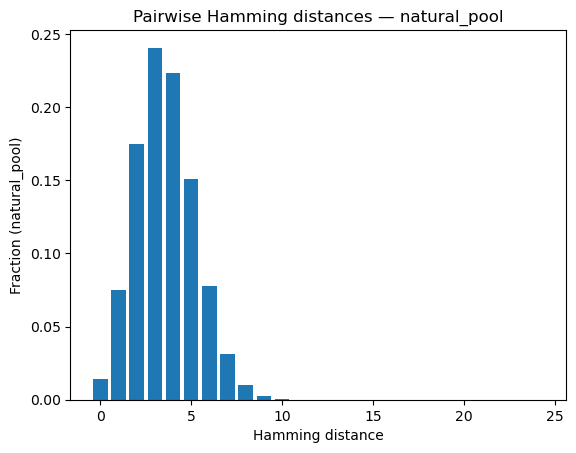

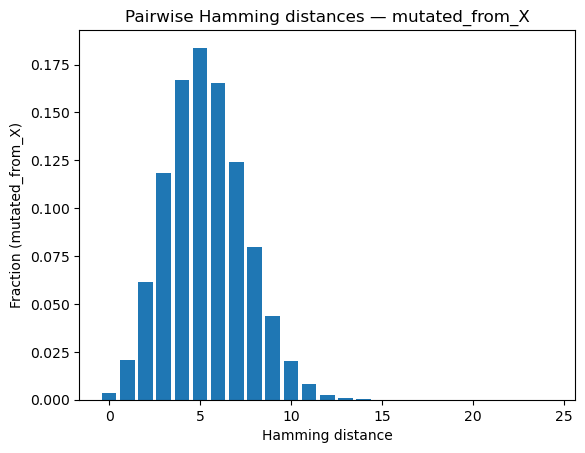

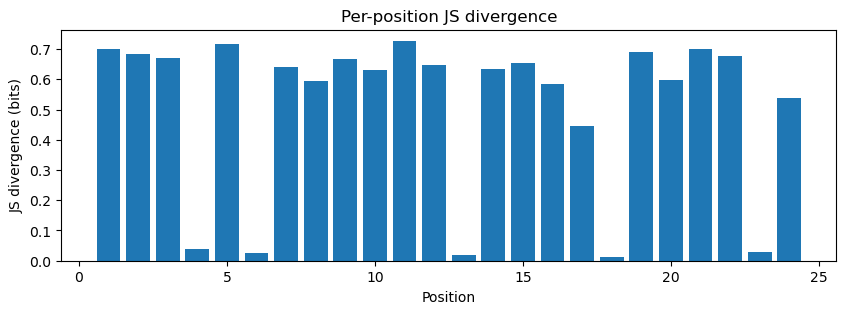

In [6]:
#FOR CDR_1 (need to change the value )
# Пример использования:
your_sequence = "ACGTACGTACGTACGTACGTACGT"  # Замените эту последовательность на вашу для анализа
pssm_path = "Downloads/cdr1_nucleotide_frequencies.csv" #путь к PSSM
# Загрузим PSSM — ожидается формат: строки = A/T/G/C, столбцы = Pos1..Pos24
raw = pd.read_csv(pssm_path)
raw = raw.set_index(raw.columns[0])

# Упорядочим ряды как A,C,G,T (на случай иной капитализации)
row_order = []
for r in ['A','C','G','T']:
    for idx in raw.index:
        if str(idx).upper() == r:
            row_order.append(idx)
            break
raw = raw.loc[row_order]

# Транспонируем к форме (positions x nucleotides)
pssm_df = raw.transpose().reset_index(drop=True)
pssm_df.columns = ['A','C','G','T']
pssm_df = pssm_df.astype(float)
pssm_df.index = range(1, 1 + pssm_df.shape[0])

# Нормализация строк (на случай, если в файле counts)
prob_mat = pssm_df[['A','C','G','T']].to_numpy()
row_sums = prob_mat.sum(axis=1, keepdims=True)
prob_mat = np.divide(prob_mat, row_sums, where=(row_sums!=0))

nt_index = {'A':0,'C':1,'G':2,'T':3}

def validate_seq(seq, L):
    seq = seq.upper().strip()
    if len(seq) != L:
        raise ValueError(f"Sequence length {len(seq)} != expected {L}.")
    if any(ch not in 'ACGT' for ch in seq):
        raise ValueError("Sequence contains non-ACGT characters.")
    return seq

def seq_log_likelihood(seq):
    seq = validate_seq(seq, prob_mat.shape[0])
    ll = 0.0
    for i,ch in enumerate(seq):
        p = prob_mat[i, nt_index[ch]]
        if p <= 0:
            ll += -1e9
        else:
            ll += math.log(p)
    return ll

def per_position_entropy(mat=None):
    if mat is None:
        mat = prob_mat
    ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
    return ent

def sample_from_pssm(n_samples=2000):
    L = prob_mat.shape[0]
    samples = []
    for _ in range(n_samples):
        seq = []
        for i in range(L):
            seq.append(random.choices(['A','C','G','T'], weights=prob_mat[i], k=1)[0])
        samples.append(''.join(seq))
    return samples

def mutate_sequence_pool(X, n_samples=2000, mean_mutations=3.0):
    L = prob_mat.shape[0]
    X = validate_seq(X, L)
    samples = []
    for _ in range(n_samples):
        k = int(np.random.poisson(mean_mutations))
        k = min(max(0, k), L)
        seq = list(X)
        if k>0:
            positions = random.sample(range(L), k)
            for pos in positions:
                probs = prob_mat[pos].copy()
                orig_idx = nt_index[seq[pos]]
                probs[orig_idx] = 0.0
                s = probs.sum()
                if s <= 0:
                    choices = [b for b in ['A','C','G','T'] if b!=seq[pos]]
                    seq[pos] = random.choice(choices)
                else:
                    probs = probs / s
                    seq[pos] = random.choices(['A','C','G','T'], weights=probs, k=1)[0]
        samples.append(''.join(seq))
    return samples

def pairwise_hamming_distance_matrix(seqs):
    n = len(seqs)
    arr = np.array([list(s) for s in seqs])
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            d = np.count_nonzero(arr[i] != arr[j])
            dists.append(d)
    return np.array(dists)

def per_position_freqs(seqs):
    L = len(seqs[0])
    freqs = np.zeros((L,4))
    for s in seqs:
        for i,ch in enumerate(s):
            freqs[i, ['A','C','G','T'].index(ch)] += 1
    freqs = freqs / freqs.sum(axis=1, keepdims=True)
    return freqs

def js_divergence(p, q):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.where(a>0, a, 1e-12)
        b = np.where(b>0, b, 1e-12)
        return np.sum(a * np.log2(a/b))
    L = p.shape[0]
    js = np.array([0.5*(kl(p[i], m[i]) + kl(q[i], m[i])) for i in range(L)])
    return js, js.mean()

# Функция для анализа последовательности
def analyze_sequence(X, N=4000, mean_mutations=3.0):
    """
    Анализирует последовательность X относительно PSSM
    
    Parameters:
    X - последовательность для проверки (должна быть длиной 24)
    N - количество образцов для генерации
    mean_mutations - среднее количество мутаций
    """
    
    # Валидация последовательности
    X = validate_seq(X, prob_mat.shape[0])
    
    # Генерация пулов последовательностей
    natural_pool = sample_from_pssm(n_samples=N)
    mutated_pool = mutate_sequence_pool(X, n_samples=N, mean_mutations=mean_mutations)
    
    # Расчет попарных расстояний
    nat_pairwise = pairwise_hamming_distance_matrix(natural_pool)
    mut_pairwise = pairwise_hamming_distance_matrix(mutated_pool)
    
    # Расчет частот и дивергенции
    nat_freqs = per_position_freqs(natural_pool)
    mut_freqs = per_position_freqs(mutated_pool)
    js_per_pos, js_mean = js_divergence(nat_freqs, mut_freqs)
    
    # Вывод результатов
    print("Sequence used (X):", X)
    print("Log-likelihood under PSSM:", seq_log_likelihood(X))
    print("Mean pairwise Hamming (natural_pool):", nat_pairwise.mean())
    print("Mean pairwise Hamming (mutated_from_X):", mut_pairwise.mean())
    print("Mean per-position JS divergence (bits):", js_mean)
    print("Per-position entropy (bits) mean:", per_position_entropy().mean())
    
    # Сохранение гистограммы попарных расстояний как CSV
    bins = list(range(0, prob_mat.shape[0]+2))
    nat_hist, _ = np.histogram(nat_pairwise, bins=bins, density=True)
    mut_hist, _ = np.histogram(mut_pairwise, bins=bins, density=True)
    hdist_df = pd.DataFrame({
        "hamming_distance": range(0, prob_mat.shape[0]+1),
        "natural_frac": np.round(nat_hist,6),
        "mutated_frac": np.round(mut_hist,6)
    })
    hdist_df.to_csv("pssm_pairwise_hamming_hist.csv", index=False)
    print("Saved histogram CSV to pssm_pairwise_hamming_hist.csv")
    
    # Графики
    plt.figure()
    plt.bar(range(len(nat_hist)), nat_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (natural_pool)')
    plt.title('Pairwise Hamming distances — natural_pool')
    plt.show()
    
    plt.figure()
    plt.bar(range(len(mut_hist)), mut_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (mutated_from_X)')
    plt.title('Pairwise Hamming distances — mutated_from_X')
    plt.show()
    
    plt.figure(figsize=(10,3))
    plt.bar(range(1, len(js_per_pos)+1), js_per_pos)
    plt.xlabel('Position')
    plt.ylabel('JS divergence (bits)')
    plt.title('Per-position JS divergence')
    plt.show()
    
    return {
        'sequence': X,
        'log_likelihood': seq_log_likelihood(X),
        'mean_hamming_natural': nat_pairwise.mean(),
        'mean_hamming_mutated': mut_pairwise.mean(),
        'js_divergence_mean': js_mean,
        'entropy_mean': per_position_entropy().mean()
    }

# Пример использования:
# Замените эту последовательность на вашу для анализа
your_sequence = "ACGTACGTACGTACGTACGTACGT"  # пример последовательности

# Запуск анализа
results = analyze_sequence(your_sequence, N=4000, mean_mutations=3.0)

Sequence used (X): ACGTACGTACGTACGTACGTACGT
Log-likelihood under PSSM: -73.93758660277288
Mean pairwise Hamming (natural_pool): 4.886754313578394
Mean pairwise Hamming (mutated_from_X): 5.278695423855964
Mean per-position JS divergence (bits): 0.5189473107674738
Per-position entropy (bits) mean: 0.6294951162689907
Saved histogram CSV to pssm_pairwise_hamming_hist.csv


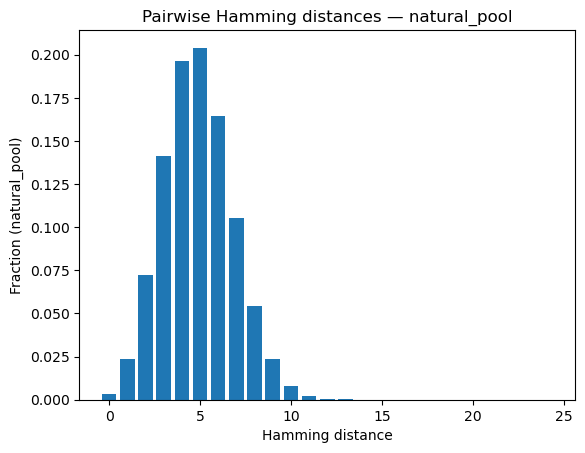

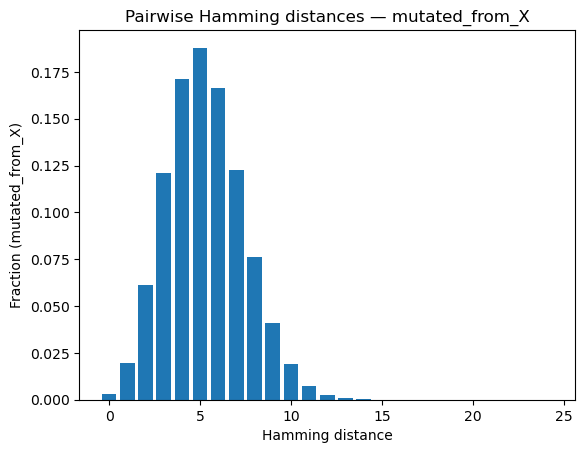

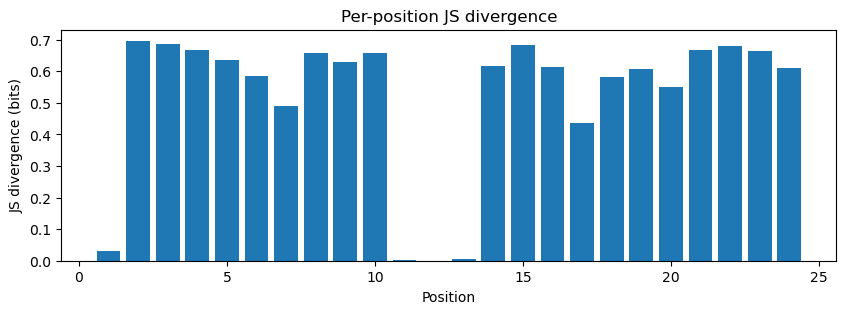

In [7]:
#FOR CDR_2 (need to change the value )
# Пример использования:
your_sequence = "ACGTACGTACGTACGTACGTACGT"  # Замените эту последовательность на вашу для анализа
pssm_path = "Downloads/cdr2_nucleotide_frequencies.csv" #путь к PSSM

# Загрузим PSSM — ожидается формат: строки = A/T/G/C, столбцы = Pos1..Pos24
raw = pd.read_csv(pssm_path)
raw = raw.set_index(raw.columns[0])

# Упорядочим ряды как A,C,G,T (на случай иной капитализации)
row_order = []
for r in ['A','C','G','T']:
    for idx in raw.index:
        if str(idx).upper() == r:
            row_order.append(idx)
            break
raw = raw.loc[row_order]

# Транспонируем к форме (positions x nucleotides)
pssm_df = raw.transpose().reset_index(drop=True)
pssm_df.columns = ['A','C','G','T']
pssm_df = pssm_df.astype(float)
pssm_df.index = range(1, 1 + pssm_df.shape[0])

# Нормализация строк (на случай, если в файле counts)
prob_mat = pssm_df[['A','C','G','T']].to_numpy()
row_sums = prob_mat.sum(axis=1, keepdims=True)
prob_mat = np.divide(prob_mat, row_sums, where=(row_sums!=0))

nt_index = {'A':0,'C':1,'G':2,'T':3}

def validate_seq(seq, L):
    seq = seq.upper().strip()
    if len(seq) != L:
        raise ValueError(f"Sequence length {len(seq)} != expected {L}.")
    if any(ch not in 'ACGT' for ch in seq):
        raise ValueError("Sequence contains non-ACGT characters.")
    return seq

def seq_log_likelihood(seq):
    seq = validate_seq(seq, prob_mat.shape[0])
    ll = 0.0
    for i,ch in enumerate(seq):
        p = prob_mat[i, nt_index[ch]]
        if p <= 0:
            ll += -1e9
        else:
            ll += math.log(p)
    return ll

def per_position_entropy(mat=None):
    if mat is None:
        mat = prob_mat
    ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
    return ent

def sample_from_pssm(n_samples=2000):
    L = prob_mat.shape[0]
    samples = []
    for _ in range(n_samples):
        seq = []
        for i in range(L):
            seq.append(random.choices(['A','C','G','T'], weights=prob_mat[i], k=1)[0])
        samples.append(''.join(seq))
    return samples

def mutate_sequence_pool(X, n_samples=2000, mean_mutations=3.0):
    L = prob_mat.shape[0]
    X = validate_seq(X, L)
    samples = []
    for _ in range(n_samples):
        k = int(np.random.poisson(mean_mutations))
        k = min(max(0, k), L)
        seq = list(X)
        if k>0:
            positions = random.sample(range(L), k)
            for pos in positions:
                probs = prob_mat[pos].copy()
                orig_idx = nt_index[seq[pos]]
                probs[orig_idx] = 0.0
                s = probs.sum()
                if s <= 0:
                    choices = [b for b in ['A','C','G','T'] if b!=seq[pos]]
                    seq[pos] = random.choice(choices)
                else:
                    probs = probs / s
                    seq[pos] = random.choices(['A','C','G','T'], weights=probs, k=1)[0]
        samples.append(''.join(seq))
    return samples

def pairwise_hamming_distance_matrix(seqs):
    n = len(seqs)
    arr = np.array([list(s) for s in seqs])
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            d = np.count_nonzero(arr[i] != arr[j])
            dists.append(d)
    return np.array(dists)

def per_position_freqs(seqs):
    L = len(seqs[0])
    freqs = np.zeros((L,4))
    for s in seqs:
        for i,ch in enumerate(s):
            freqs[i, ['A','C','G','T'].index(ch)] += 1
    freqs = freqs / freqs.sum(axis=1, keepdims=True)
    return freqs

def js_divergence(p, q):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.where(a>0, a, 1e-12)
        b = np.where(b>0, b, 1e-12)
        return np.sum(a * np.log2(a/b))
    L = p.shape[0]
    js = np.array([0.5*(kl(p[i], m[i]) + kl(q[i], m[i])) for i in range(L)])
    return js, js.mean()

# Функция для анализа последовательности
def analyze_sequence(X, N=4000, mean_mutations=3.0):
    """
    Анализирует последовательность X относительно PSSM
    
    Parameters:
    X - последовательность для проверки (должна быть длиной 24)
    N - количество образцов для генерации
    mean_mutations - среднее количество мутаций
    """
    
    # Валидация последовательности
    X = validate_seq(X, prob_mat.shape[0])
    
    # Генерация пулов последовательностей
    natural_pool = sample_from_pssm(n_samples=N)
    mutated_pool = mutate_sequence_pool(X, n_samples=N, mean_mutations=mean_mutations)
    
    # Расчет попарных расстояний
    nat_pairwise = pairwise_hamming_distance_matrix(natural_pool)
    mut_pairwise = pairwise_hamming_distance_matrix(mutated_pool)
    
    # Расчет частот и дивергенции
    nat_freqs = per_position_freqs(natural_pool)
    mut_freqs = per_position_freqs(mutated_pool)
    js_per_pos, js_mean = js_divergence(nat_freqs, mut_freqs)
    
    # Вывод результатов
    print("Sequence used (X):", X)
    print("Log-likelihood under PSSM:", seq_log_likelihood(X))
    print("Mean pairwise Hamming (natural_pool):", nat_pairwise.mean())
    print("Mean pairwise Hamming (mutated_from_X):", mut_pairwise.mean())
    print("Mean per-position JS divergence (bits):", js_mean)
    print("Per-position entropy (bits) mean:", per_position_entropy().mean())
    
    # Сохранение гистограммы попарных расстояний как CSV
    bins = list(range(0, prob_mat.shape[0]+2))
    nat_hist, _ = np.histogram(nat_pairwise, bins=bins, density=True)
    mut_hist, _ = np.histogram(mut_pairwise, bins=bins, density=True)
    hdist_df = pd.DataFrame({
        "hamming_distance": range(0, prob_mat.shape[0]+1),
        "natural_frac": np.round(nat_hist,6),
        "mutated_frac": np.round(mut_hist,6)
    })
    hdist_df.to_csv("pssm_pairwise_hamming_hist.csv", index=False)
    print("Saved histogram CSV to pssm_pairwise_hamming_hist.csv")
    
    # Графики
    plt.figure()
    plt.bar(range(len(nat_hist)), nat_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (natural_pool)')
    plt.title('Pairwise Hamming distances — natural_pool')
    plt.show()
    
    plt.figure()
    plt.bar(range(len(mut_hist)), mut_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (mutated_from_X)')
    plt.title('Pairwise Hamming distances — mutated_from_X')
    plt.show()
    
    plt.figure(figsize=(10,3))
    plt.bar(range(1, len(js_per_pos)+1), js_per_pos)
    plt.xlabel('Position')
    plt.ylabel('JS divergence (bits)')
    plt.title('Per-position JS divergence')
    plt.show()
    
    return {
        'sequence': X,
        'log_likelihood': seq_log_likelihood(X),
        'mean_hamming_natural': nat_pairwise.mean(),
        'mean_hamming_mutated': mut_pairwise.mean(),
        'js_divergence_mean': js_mean,
        'entropy_mean': per_position_entropy().mean()
    }



# Запуск анализа
results = analyze_sequence(your_sequence, N=4000, mean_mutations=3.0)